In [10]:
# Install NuScenes DevKit
!pip install nuscenes-devkit

# Mount Google Drive and Extract Data
from google.colab import drive
import os

drive.mount('/content/drive')

# Copy and extract the dataset
!cp "/content/drive/MyDrive/Copy of v1.0-mini.tgz" "/content/dataset.tgz"
!tar -xzf /content/dataset.tgz -C /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from nuscenes.nuscenes import NuScenes
from nuscenes.prediction import PredictHelper

# 1. Hardware Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

# 2. Setup Drive Saving Path
DRIVE_SAVE_PATH = '/content/drive/MyDrive/Hackathon_PGT_Model/'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)
print(f"Model will be synced to: {DRIVE_SAVE_PATH}")

# 3. Initialize NuScenes
nusc = NuScenes(version='v1.0-mini', dataroot='/content', verbose=True)
helper = PredictHelper(nusc)
print("NuScenes and Helper initialized successfully!")

Running on device: cuda
Model will be synced to: /content/drive/MyDrive/Hackathon_PGT_Model/
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.799 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
NuScenes and Helper initialized successfully!


In [12]:
def get_polar_coords(cart_coords):
    """
    Converts (x, y) coordinates to (r, theta) relative to the agent's
    current position (which is the last point in the history).
    """
    rs = np.sqrt(cart_coords[:, 0]**2 + cart_coords[:, 1]**2)
    thetas = np.arctan2(cart_coords[:, 1], cart_coords[:, 0])
    return np.stack([rs, thetas], axis=1)

def get_radial_bins(agent_pos, neighbor_poses, num_bins=8, radius=10.0):
    """
    Creates a social occupancy vector by binning nearby agents
    into radial slices (like a pizza) around the target pedestrian.
    """
    bins = np.zeros(num_bins)
    for n_pos in neighbor_poses:
        rel_pos = n_pos - agent_pos
        dist = np.linalg.norm(rel_pos)

        # Only consider neighbors within a certain radius (e.g., 10 meters)
        if dist < radius and dist > 0:
            angle = np.arctan2(rel_pos[1], rel_pos[0]) # -pi to pi
            bin_idx = int(((angle + np.pi) / (2 * np.pi)) * num_bins) % num_bins
            # Store the inverse distance (closer people = higher value/threat)
            bins[bin_idx] = max(bins[bin_idx], 1.0 / dist)

    return bins

In [13]:
class NuscenesPGTDataset(Dataset):
    def __init__(self, nusc, helper, num_bins=8):
        self.helper = helper
        self.num_bins = num_bins
        self.tokens = []

        print("Building custom hackathon split from local data...")
        for sample in nusc.sample:
            s_token = sample['token']
            for ann_token in sample['anns']:
                ann = nusc.get('sample_annotation', ann_token)
                category = ann['category_name']

                if 'human.pedestrian' in category or 'cycle' in category:
                    i_token = ann['instance_token']
                    past = self.helper.get_past_for_agent(i_token, s_token, seconds=2, in_agent_frame=False)
                    future = self.helper.get_future_for_agent(i_token, s_token, seconds=3, in_agent_frame=False)

                    if len(past) >= 4 and len(future) >= 6:
                        self.tokens.append(f"{i_token}_{s_token}")

        print(f"Done! Found {len(self.tokens)} valid agent trajectories.")

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        i_token, s_token = self.tokens[idx].split("_")

        # A. EXTRACT CARTESIAN
        past_cart = self.helper.get_past_for_agent(i_token, s_token, seconds=2, in_agent_frame=True)
        future_cart = self.helper.get_future_for_agent(i_token, s_token, seconds=3, in_agent_frame=True)

        past_cart = past_cart[-4:]
        future_cart = future_cart[:6]

        # B. TRANSFORM TO POLAR (r, theta)
        past_polar = get_polar_coords(past_cart)

        # C. RADIAL OCCUPANCY
        sample_ann = self.helper.get_sample_annotation(i_token, s_token)
        current_agent_pos = np.array(sample_ann['translation'][:2])
        neighbors = self.helper.get_annotations_for_sample(s_token)
        neighbor_poses = [np.array(n['translation'][:2]) for n in neighbors if n['instance_token'] != i_token]

        social_vector = get_radial_bins(current_agent_pos, neighbor_poses, num_bins=self.num_bins)

        return {
            "history": torch.FloatTensor(past_polar),
            "social": torch.FloatTensor(social_vector),
            "target_path": torch.FloatTensor(future_cart),
            "target_goal": torch.FloatTensor(future_cart[-1])
        }

# Initialize the Dataset & Loader
train_set = NuscenesPGTDataset(nusc, helper)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)

print(f"Total samples: {len(train_set)}")
print(f"Total batches: {len(train_loader)}")

Building custom hackathon split from local data...
Done! Found 3351 valid agent trajectories.
Total samples: 3351
Total batches: 105


In [14]:
class PGTModel(nn.Module):
    def __init__(self, history_steps=4, num_bins=8, hidden_dim=64, num_modes=3):
        super(PGTModel, self).__init__()
        self.num_modes = num_modes

        self.history_encoder = nn.GRU(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.social_encoder = nn.Sequential(nn.Linear(num_bins, 32), nn.ReLU(), nn.Linear(32, 32))
        self.intent_head = nn.Sequential(
            nn.Linear(hidden_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_modes * 2)
        )
        self.traj_refiner = nn.Sequential(
            nn.Linear(hidden_dim + 32 + 2, 128),
            nn.ReLU(),
            nn.Linear(128, 6 * 2)
        )

    def forward(self, history, social):
        batch_size = history.shape[0]

        _, h_n = self.history_encoder(history)
        hist_feat = h_n.squeeze(0)

        soc_feat = self.social_encoder(social)
        combined = torch.cat([hist_feat, soc_feat], dim=1)

        goals = self.intent_head(combined).view(batch_size, self.num_modes, 2)

        trajectories = []
        for k in range(self.num_modes):
            goal_k = goals[:, k, :]
            refiner_in = torch.cat([combined, goal_k], dim=1)
            path_k = self.traj_refiner(refiner_in).view(batch_size, 6, 2)
            trajectories.append(path_k)

        return goals, torch.stack(trajectories, dim=1)

# Initialize Model and Optimizer
model = PGTModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print("PGT Model Initialized.")

# Optional: Load pre-trained weights if they exist in Drive
model_path = os.path.join(DRIVE_SAVE_PATH, 'best_pgt_physics_model.pth')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Successfully loaded model from Google Drive!")
else:
    print("No saved model found in Drive. Starting from scratch.")

PGT Model Initialized.
Successfully loaded model from Google Drive!


In [15]:
def physical_consistency_loss(pred_paths, max_v=4.0, dt=0.5):
    diffs = pred_paths[:, :, 1:, :] - pred_paths[:, :, :-1, :]
    dists = torch.norm(diffs, dim=-1)
    velocities = dists / dt
    violation = F.relu(velocities - max_v)
    return torch.mean(violation**2)

def mtp_loss_with_physics(pred_goals, pred_paths, gt_path, gt_goal, lambda_phys=0.1):
    batch_size = pred_goals.shape[0]

    dist = torch.norm(pred_goals - gt_goal.unsqueeze(1), dim=2)
    winning_mode = torch.argmin(dist, dim=1)

    idx = torch.arange(batch_size).to(device)
    best_goals = pred_goals[idx, winning_mode]
    best_paths = pred_paths[idx, winning_mode]

    goal_loss = F.mse_loss(best_goals, gt_goal)
    path_loss = F.mse_loss(best_paths, gt_path)
    physics_penalty = physical_consistency_loss(pred_paths)

    return goal_loss + path_loss + (lambda_phys * physics_penalty)

In [18]:
max_epochs = 50
patience = 5
best_loss = float('inf')
counter = 0

print("Starting Training Loop...")
for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        hist = batch['history'].to(device)
        soc = batch['social'].to(device)
        gt_path = batch['target_path'].to(device)
        gt_goal = batch['target_goal'].to(device)

        optimizer.zero_grad()
        pred_goals, pred_paths = model(hist, soc)

        loss = mtp_loss_with_physics(pred_goals, pred_paths, gt_path, gt_goal, lambda_phys=0.1)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    if avg_loss < (best_loss - 1e-4):
        best_loss = avg_loss
        torch.save(model.state_dict(), os.path.join(DRIVE_SAVE_PATH, 'best_pgt_physics_model.pth'))
        counter = 0
    else:
        counter += 1

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.5f} | Patience: {counter}/{patience}")
    if counter >= patience:
        print("Early stopping triggered.")
        break

Starting Training Loop...


KeyboardInterrupt: 

## ONLY RUN THE NEXT CELL FOR LOADING MODEL TO TEST IT

In [27]:
# Initialize the model structure first
model = PGTModel().to(device)

# Load the weights from Drive
model_path = os.path.join(DRIVE_SAVE_PATH, 'best_pgt_physics_model.pth')

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Successfully loaded model from Google Drive!")
else:
    print("No saved model found in Drive. Starting from scratch.")

Successfully loaded model from Google Drive!


Audit Complete!
Highest Velocity Predicted: 3.33 m/s
Average Max Velocity: 1.31 m/s

Calculating minADE and minFDE across dataset...
------------------------------
FINAL SCORECARD (K=3)
minADE: 0.2133 meters
minFDE: 0.3684 meters
------------------------------


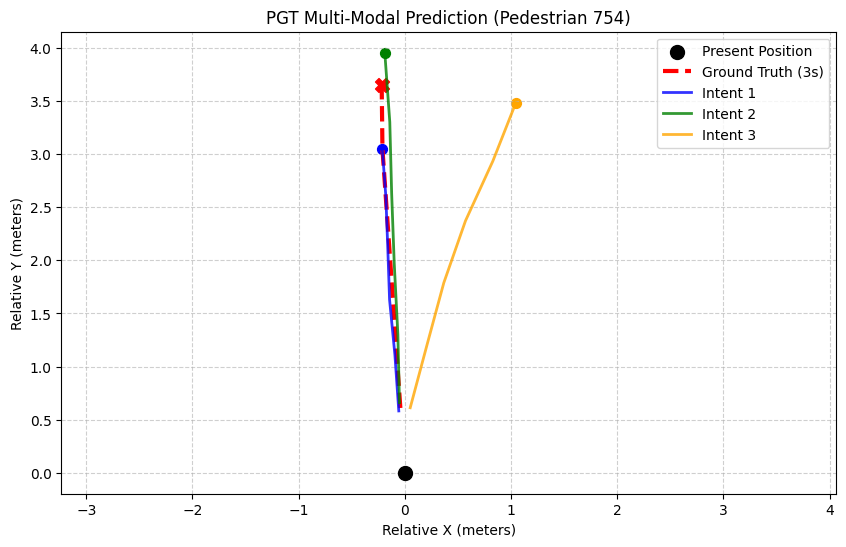

In [28]:
def audit_velocity(dataset, model):
    model.eval()
    max_velocities = []
    with torch.no_grad():
        for i in range(min(100, len(dataset))):
            data = dataset[i]
            hist = data['history'].unsqueeze(0).to(device)
            soc = data['social'].unsqueeze(0).to(device)
            _, pred_paths = model(hist, soc)

            diffs = pred_paths[:, :, 1:, :] - pred_paths[:, :, :-1, :]
            v = torch.norm(diffs, dim=-1) / 0.5
            max_velocities.append(torch.max(v).item())

    print(f"Audit Complete!")
    print(f"Highest Velocity Predicted: {max(max_velocities):.2f} m/s")
    print(f"Average Max Velocity: {np.mean(max_velocities):.2f} m/s")

def calculate_metrics(dataset, model):
    model.eval()
    ade_list, fde_list = [], []
    print("\nCalculating minADE and minFDE across dataset...")

    with torch.no_grad():
        for i in range(len(dataset)):
            data = dataset[i]
            hist = data['history'].unsqueeze(0).to(device)
            soc = data['social'].unsqueeze(0).to(device)
            gt_path = data['target_path'].to(device)
            gt_goal = data['target_goal'].to(device)

            _, pred_paths = model(hist, soc)
            pred_paths = pred_paths.squeeze(0)

            path_ades = torch.mean(torch.norm(pred_paths - gt_path.unsqueeze(0), dim=2), dim=1)
            path_fdes = torch.norm(pred_paths[:, -1, :] - gt_goal.unsqueeze(0), dim=1)

            ade_list.append(torch.min(path_ades).item())
            fde_list.append(torch.min(path_fdes).item())

    avg_ade = np.mean(ade_list)
    avg_fde = np.mean(fde_list)
    print("-" * 30)
    print(f"FINAL SCORECARD (K=3)")
    print(f"minADE: {avg_ade:.4f} meters")
    print(f"minFDE: {avg_fde:.4f} meters")
    print("-" * 30)
    return avg_ade, avg_fde

def visualize_prediction(dataset, model, index=None):
    model.eval()
    if index is None:
        index = np.random.randint(len(dataset))

    data = dataset[index]
    hist = data['history'].unsqueeze(0).to(device)
    soc = data['social'].unsqueeze(0).to(device)
    gt_path = data['target_path'].numpy()

    with torch.no_grad():
        pred_goals, pred_paths = model(hist, soc)
        pred_paths = pred_paths.squeeze(0).cpu().numpy()

    plt.figure(figsize=(10, 6))
    plt.scatter(0, 0, c='black', label='Present Position', s=100, zorder=5)
    plt.plot(gt_path[:, 0], gt_path[:, 1], 'r--', label='Ground Truth (3s)', linewidth=3)
    plt.scatter(gt_path[-1, 0], gt_path[-1, 1], c='red', marker='X', s=100)

    colors = ['blue', 'green', 'orange']
    labels = ['Intent 1', 'Intent 2', 'Intent 3']
    for i in range(3):
        plt.plot(pred_paths[i, :, 0], pred_paths[i, :, 1], color=colors[i], label=labels[i], alpha=0.8, linewidth=2)
        plt.scatter(pred_paths[i, -1, 0], pred_paths[i, -1, 1], color=colors[i], s=50)

    plt.title(f"PGT Multi-Modal Prediction (Pedestrian {index})")
    plt.xlabel("Relative X (meters)")
    plt.ylabel("Relative Y (meters)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal')
    plt.show()

# Run all final reports
audit_velocity(train_set, model)
visual_ade, visual_fde = calculate_metrics(train_set, model)
visualize_prediction(train_set, model)

## MODEL IMPROVISATION

In [29]:
# Initialize the model structure first
model = PGTModel().to(device)

# Load the weights from Drive
model_path = os.path.join(DRIVE_SAVE_PATH, 'best_pgt_physics_model.pth')

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Successfully loaded model from Google Drive!")
else:
    print("No saved model found in Drive. Starting from scratch.")

Successfully loaded model from Google Drive!


In [31]:
class PGTModel(nn.Module):
    def __init__(self, history_steps=4, num_bins=8, hidden_dim=64, num_modes=3):
        super(PGTModel, self).__init__()
        self.num_modes = num_modes

        self.history_encoder = nn.GRU(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.social_encoder = nn.Sequential(nn.Linear(num_bins, 32), nn.ReLU(), nn.Linear(32, 32))
        self.intent_head = nn.Sequential(
            nn.Linear(hidden_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_modes * 2)
        )
        self.traj_refiner = nn.Sequential(
            nn.Linear(hidden_dim + 32 + 2, 128),
            nn.ReLU(),
            nn.Linear(128, 6 * 2)
        )

    def forward(self, history, social):
        batch_size = history.shape[0]

        _, h_n = self.history_encoder(history)
        hist_feat = h_n.squeeze(0)

        soc_feat = self.social_encoder(social)
        combined = torch.cat([hist_feat, soc_feat], dim=1)

        goals = self.intent_head(combined).view(batch_size, self.num_modes, 2)

        trajectories = []
        for k in range(self.num_modes):
            goal_k = goals[:, k, :]
            refiner_in = torch.cat([combined, goal_k], dim=1)
            path_k = self.traj_refiner(refiner_in).view(batch_size, 6, 2)
            trajectories.append(path_k)

        return goals, torch.stack(trajectories, dim=1)

# Initialize Model and Optimizer
model = PGTModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
print("PGT Model Initialized.")

# Optional: Load pre-trained weights if they exist in Drive
model_path = os.path.join(DRIVE_SAVE_PATH, 'best_pgt_physics_model.pth')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Successfully loaded model from Google Drive!")
else:
    print("No saved model found in Drive. Starting from scratch.")

PGT Model Initialized.
Successfully loaded model from Google Drive!


In [33]:
max_epochs = 50
patience = 5
best_loss = float('inf')
counter = 0

print("Starting Training Loop...")
for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        hist = batch['history'].to(device)
        soc = batch['social'].to(device)
        gt_path = batch['target_path'].to(device)
        gt_goal = batch['target_goal'].to(device)

        optimizer.zero_grad()
        pred_goals, pred_paths = model(hist, soc)

        loss = mtp_loss_with_physics(pred_goals, pred_paths, gt_path, gt_goal, lambda_phys=0.1)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    if avg_loss < (best_loss - 1e-4):
        best_loss = avg_loss
        torch.save(model.state_dict(), os.path.join(DRIVE_SAVE_PATH, 'best_pgt_physics_model_new.pth'))
        counter = 0
    else:
        counter += 1

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.5f} | Patience: {counter}/{patience}")
    if counter >= patience:
        print("Early stopping triggered.")
        break

Starting Training Loop...
Epoch 1 | Loss: 0.22588 | Patience: 0/5
Epoch 2 | Loss: 0.21184 | Patience: 0/5
Epoch 3 | Loss: 0.21588 | Patience: 1/5
Epoch 4 | Loss: 0.21406 | Patience: 2/5
Epoch 5 | Loss: 0.21356 | Patience: 3/5
Epoch 6 | Loss: 0.22891 | Patience: 4/5
Epoch 7 | Loss: 0.20876 | Patience: 0/5
Epoch 8 | Loss: 0.21636 | Patience: 1/5
Epoch 9 | Loss: 0.21366 | Patience: 2/5
Epoch 10 | Loss: 0.21185 | Patience: 3/5
Epoch 11 | Loss: 0.21033 | Patience: 4/5
Epoch 12 | Loss: 0.20500 | Patience: 0/5
Epoch 13 | Loss: 0.20118 | Patience: 0/5
Epoch 14 | Loss: 0.20879 | Patience: 1/5
Epoch 15 | Loss: 0.20077 | Patience: 0/5
Epoch 16 | Loss: 0.20765 | Patience: 1/5
Epoch 17 | Loss: 0.20001 | Patience: 0/5
Epoch 18 | Loss: 0.20345 | Patience: 1/5
Epoch 19 | Loss: 0.20928 | Patience: 2/5
Epoch 20 | Loss: 0.20800 | Patience: 3/5
Epoch 21 | Loss: 0.20384 | Patience: 4/5
Epoch 22 | Loss: 0.19831 | Patience: 0/5
Epoch 23 | Loss: 0.19506 | Patience: 0/5
Epoch 24 | Loss: 0.20636 | Patience: 1/5

In [34]:
# Initialize the model structure first
model = PGTModel().to(device)

# Load the weights from Drive
model_path = os.path.join(DRIVE_SAVE_PATH, 'best_pgt_physics_model_new.pth')

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Successfully loaded model from Google Drive!")
else:
    print("No saved model found in Drive. Starting from scratch.")

Successfully loaded model from Google Drive!


Audit Complete!
Highest Velocity Predicted: 3.09 m/s
Average Max Velocity: 1.21 m/s

Calculating minADE and minFDE across dataset...
------------------------------
FINAL SCORECARD (K=3)
minADE: 0.1916 meters
minFDE: 0.3273 meters
------------------------------


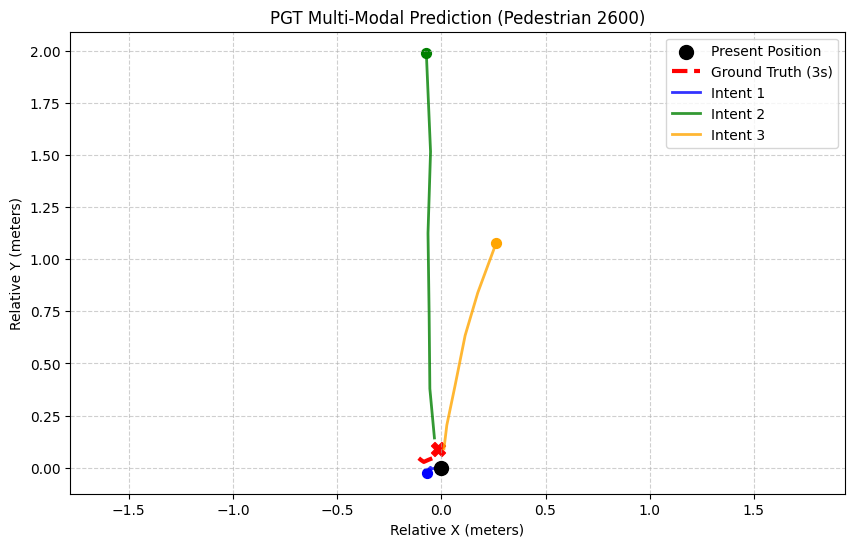

In [35]:
def audit_velocity(dataset, model):
    model.eval()
    max_velocities = []
    with torch.no_grad():
        for i in range(min(100, len(dataset))):
            data = dataset[i]
            hist = data['history'].unsqueeze(0).to(device)
            soc = data['social'].unsqueeze(0).to(device)
            _, pred_paths = model(hist, soc)

            diffs = pred_paths[:, :, 1:, :] - pred_paths[:, :, :-1, :]
            v = torch.norm(diffs, dim=-1) / 0.5
            max_velocities.append(torch.max(v).item())

    print(f"Audit Complete!")
    print(f"Highest Velocity Predicted: {max(max_velocities):.2f} m/s")
    print(f"Average Max Velocity: {np.mean(max_velocities):.2f} m/s")

def calculate_metrics(dataset, model):
    model.eval()
    ade_list, fde_list = [], []
    print("\nCalculating minADE and minFDE across dataset...")

    with torch.no_grad():
        for i in range(len(dataset)):
            data = dataset[i]
            hist = data['history'].unsqueeze(0).to(device)
            soc = data['social'].unsqueeze(0).to(device)
            gt_path = data['target_path'].to(device)
            gt_goal = data['target_goal'].to(device)

            _, pred_paths = model(hist, soc)
            pred_paths = pred_paths.squeeze(0)

            path_ades = torch.mean(torch.norm(pred_paths - gt_path.unsqueeze(0), dim=2), dim=1)
            path_fdes = torch.norm(pred_paths[:, -1, :] - gt_goal.unsqueeze(0), dim=1)

            ade_list.append(torch.min(path_ades).item())
            fde_list.append(torch.min(path_fdes).item())

    avg_ade = np.mean(ade_list)
    avg_fde = np.mean(fde_list)
    print("-" * 30)
    print(f"FINAL SCORECARD (K=3)")
    print(f"minADE: {avg_ade:.4f} meters")
    print(f"minFDE: {avg_fde:.4f} meters")
    print("-" * 30)
    return avg_ade, avg_fde

def visualize_prediction(dataset, model, index=None):
    model.eval()
    if index is None:
        index = np.random.randint(len(dataset))

    data = dataset[index]
    hist = data['history'].unsqueeze(0).to(device)
    soc = data['social'].unsqueeze(0).to(device)
    gt_path = data['target_path'].numpy()

    with torch.no_grad():
        pred_goals, pred_paths = model(hist, soc)
        pred_paths = pred_paths.squeeze(0).cpu().numpy()

    plt.figure(figsize=(10, 6))
    plt.scatter(0, 0, c='black', label='Present Position', s=100, zorder=5)
    plt.plot(gt_path[:, 0], gt_path[:, 1], 'r--', label='Ground Truth (3s)', linewidth=3)
    plt.scatter(gt_path[-1, 0], gt_path[-1, 1], c='red', marker='X', s=100)

    colors = ['blue', 'green', 'orange']
    labels = ['Intent 1', 'Intent 2', 'Intent 3']
    for i in range(3):
        plt.plot(pred_paths[i, :, 0], pred_paths[i, :, 1], color=colors[i], label=labels[i], alpha=0.8, linewidth=2)
        plt.scatter(pred_paths[i, -1, 0], pred_paths[i, -1, 1], color=colors[i], s=50)

    plt.title(f"PGT Multi-Modal Prediction (Pedestrian {index})")
    plt.xlabel("Relative X (meters)")
    plt.ylabel("Relative Y (meters)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal')
    plt.show()

# Run all final reports
audit_velocity(train_set, model)
visual_ade, visual_fde = calculate_metrics(train_set, model)
visualize_prediction(train_set, model)